In [1]:
import torch
import numpy as np
from matplotlib import pyplot as plt

import utilities as utils
import care

# Training the global operator on real-world data

### Stationary real-world dataset

The real-world data include a stationary 440 Hz signal.


inf >> dataset parameters:

 dataset  batches  timeseries length channels
--------  -------  ----------------- --------
   train     3500                200        1
   valid     1000                200        1
    test      500                200        1



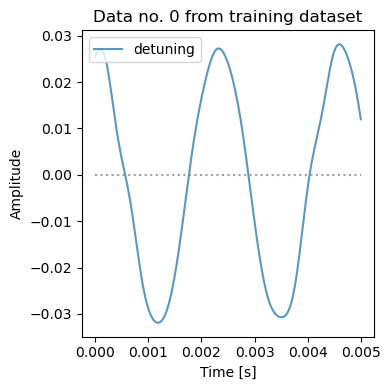

In [2]:
# --!------------------------------------------------------!
# --! display dataset metrics

dataset_dir     = 'cavity/train_meas_g'
timeseries_len  = 200
timestep        = 2.5e-5
x_dims_n        = 1
x_len           = 200
utils.disp_dataset(dataset_dir, timeseries_len, timestep, data_n=1)

### Model instantiation

As in the synthetic case, the model is instantiated with 4 basis functions: a sine and a cosine, as well as 2 data-driven functions. We also set parameter $\tau=40$ to align with the synthetic example. Of course, as or real-world data feature a single oscillatory mode then the DMD-like global operator will identify only one complex pair of eigenvalues.

In [3]:
# --!--------------------------------------------------------------------------
# --! instantiate a model

# --! ensure reproducible results
seed = 5
torch.manual_seed(seed)

cfg = care.config(

    timeseries_dims_n     = x_dims_n,
    timeseries_sz         = x_len,
    timeseries_timestep   = timestep,

    funs={
        'sin'   : 2,
        'cos'   : 2,
        'data1' : 1,
        'data2' : 1,
    },
    fun_params_kern_sz    = 40,

    fit_weight_lin_global = 1.,
    fit_weight_lin_local  = 0.
)

model = care.detune(cfg)

### Global operator training

In [4]:
# --!--------------------------------------------------------------------------
# --! train the global operator

train_params = {
    'dataset_dir'   : dataset_dir,
    'timeseries_sz' : timeseries_len,
    'train_files_n' : 7,
    'batch_sz'      : 128,
    'epochs_n'      : 100,
    'x_sz'          : x_len,
    'is_verbose'    : True,
    'is_global'     : True,
    'learn_rate'    : 1e-3,
    'weight_decay'  : 1e-8,
    'alpha'         : 1.0
}

outs = utils.train(model, train_params)

loss_train_pred  = outs[0]
loss_train_lin_g = outs[1]
loss_train_lin_l = outs[2]
loss_valid_pred  = outs[3]
loss_valid_lin_g = outs[4]
loss_valid_lin_l = outs[5]

inf >> Number of data files for training : 7
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> processing training file number 4
inf >> processing training file number 5
inf >> processing training file number 6
inf >> processing training file number 7


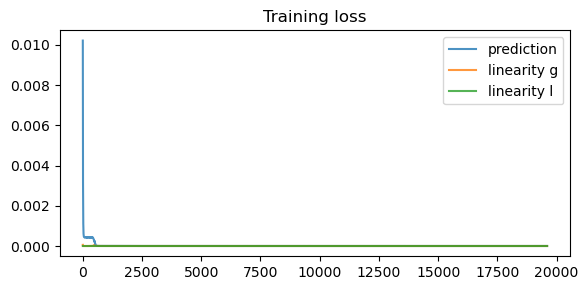

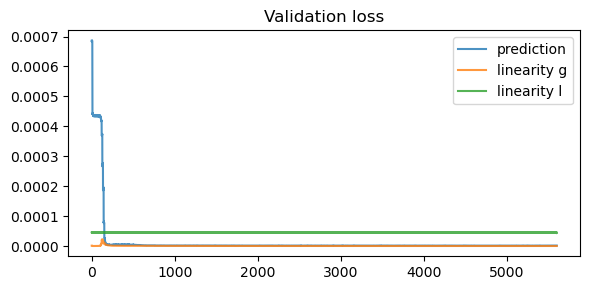

In [5]:
# --!--------------------------------------------------------------------------
# --! display training and validation statistics

with torch.no_grad():
    plt.figure(figsize=(6, 3))
    plt.title('Training loss')
    plt.plot(loss_train_pred, alpha=0.8, label='prediction')
    plt.plot(loss_train_lin_g, alpha=0.8, label='linearity g')
    plt.plot(loss_train_lin_l, alpha=0.8, label='linearity l')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 3))
    plt.title('Validation loss')
    plt.plot(loss_valid_pred, alpha=0.8, label='prediction')
    plt.plot(loss_valid_lin_g, alpha=0.8, label='linearity g')
    plt.plot(loss_valid_lin_l, alpha=0.8, label='linearity l')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
# --!--------------------------------------------------------------------------
# --! save a trained global model

savemod_on = True

if savemod_on:
    torch.save(model, 'data/models/care_meas_g.pt')

### Analysis of global operator eigenvalues

The trained operator successfully identifies the single mode present in the data, hence one pair of complex eigenvalues. The fact that this pair resides on the unit circle reflects the absense of decay in the real-world data. The other two eigenvalues are real.

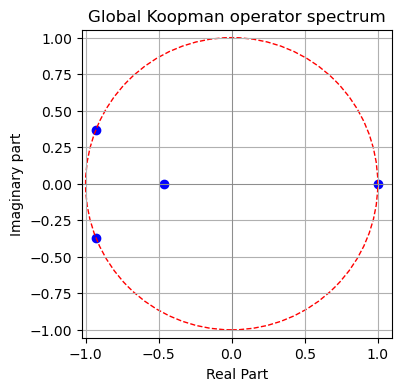

In [6]:
# --!--------------------------------------------------------------------------
# --! visualize global operator eigenvalues

with torch.no_grad():
    eigvals, eigvecs = torch.linalg.eig(model.timeseries_dyn.weight)
    utils.disp_spectrum(eigvals)

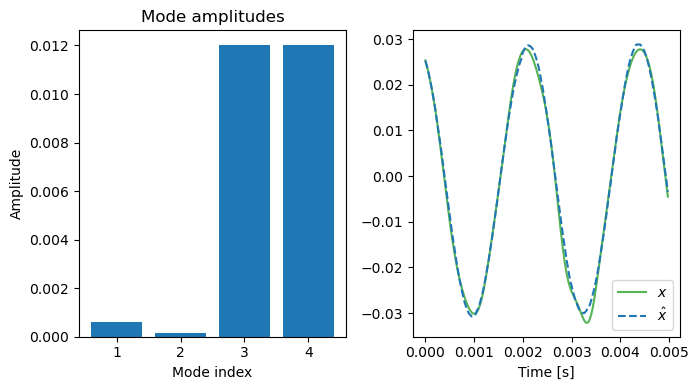

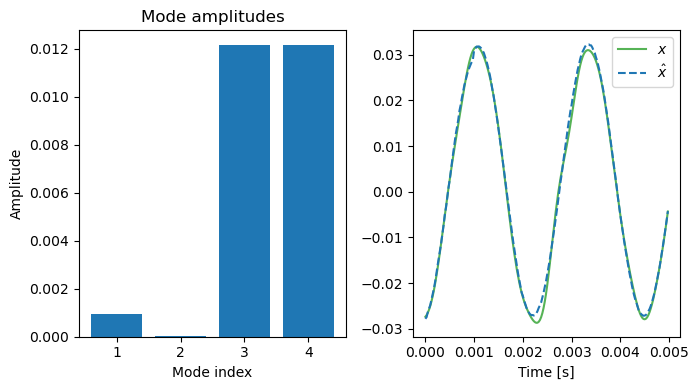

In [10]:
# --!--------------------------------------------------------------------------
# --! analyze the amplitude of global operator eigenvalues

with torch.no_grad():
    for i in range(2):
        utils.disp_spectrum_amps(model, dataset_dir, timeseries_len, i)

In [ ]:
# --!--------------------------------------------------------------------------
# --! save a trained global model

savemod_on = False
print(model.timeseries_dyn.weight)

if savemod_on:
    torch.save(model, 'data/models/care_global_meas.pt')

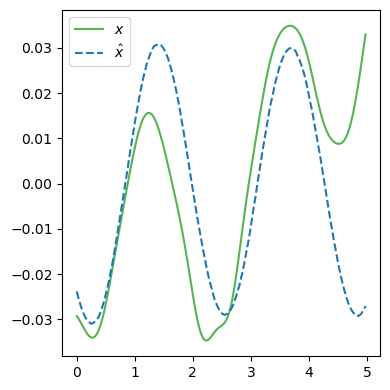

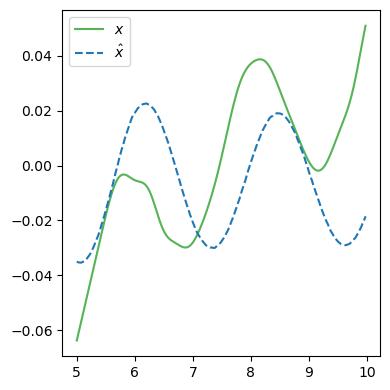

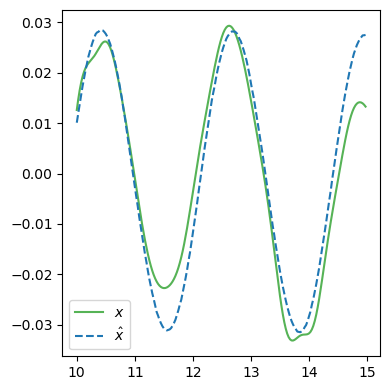

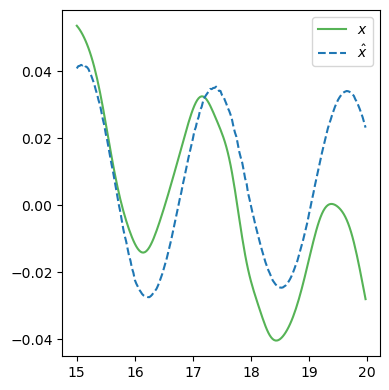

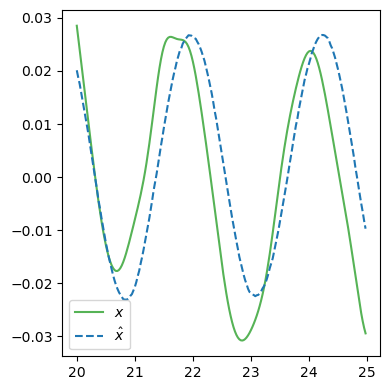

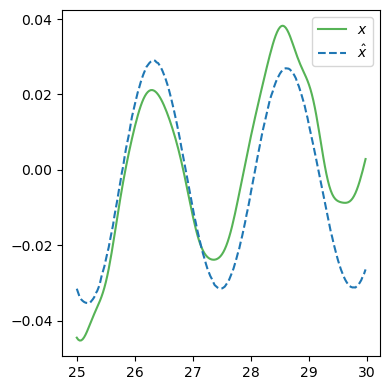

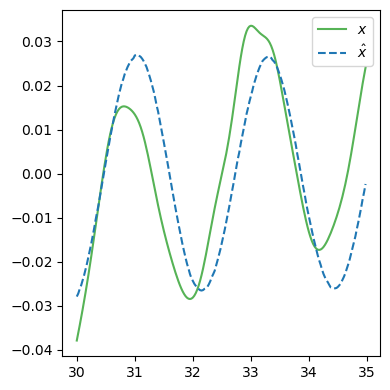

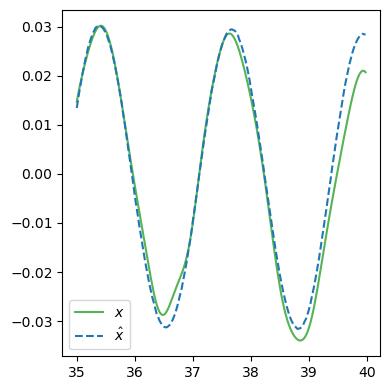

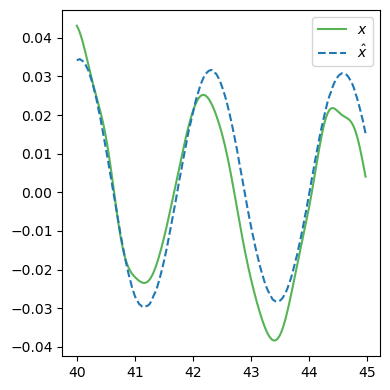

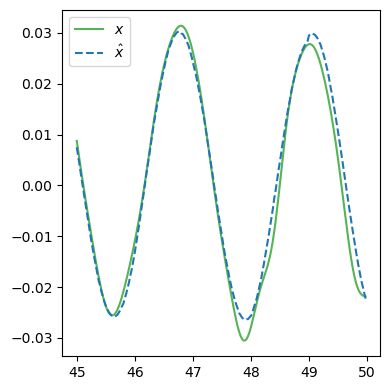

inf >> prediction loss in evaluation is 2.050894e-04


In [13]:
# --!--------------------------------------------------------------------------
# --! evaluate model

eval_ts_len       = 200
eval_timestep     = 2.5e-5
eval_dataset_dir  = 'cavity/eval_meas'

eval_data = utils.read_datafile(f'{eval_dataset_dir}/eval', eval_ts_len)

with torch.no_grad():
    data = torch.split(eval_data, 1, dim=0)
    for this, datum in enumerate(data):
        datum = datum[:, :x_len, :1]

        outs = model(datum, alpha=1.0)
        timeseries_pred = outs[4]

        timeseries = torch.squeeze(datum, dim=0)
        timeseries_pred = torch.squeeze(timeseries_pred, dim=0)

        t = np.arange(0., eval_ts_len*eval_timestep, eval_timestep).reshape(-1, 1) * 1e3
        t = t + this*5

        plt.figure(figsize=(4,4))
        plt.plot(t[:x_len, 0], timeseries[:x_len, 0], alpha=0.8, color='tab:green', label='$x$')
        plt.plot(t[:x_len, 0], timeseries_pred[:, 0], alpha=1, color='tab:blue', linestyle='dashed', label='$\\hat{x}$')
        plt.legend()
        plt.tight_layout()
        plt.show()